In [6]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *
from triqs_tprf.lattice import lattice_dyson_g0_wk, lattice_dyson_g_wk, lindhard_chi00

import seaborn as sns
color_list = sns.color_palette() + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

# single run with and without refinent (maybe also compare with tprc method)
# rest with more runs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


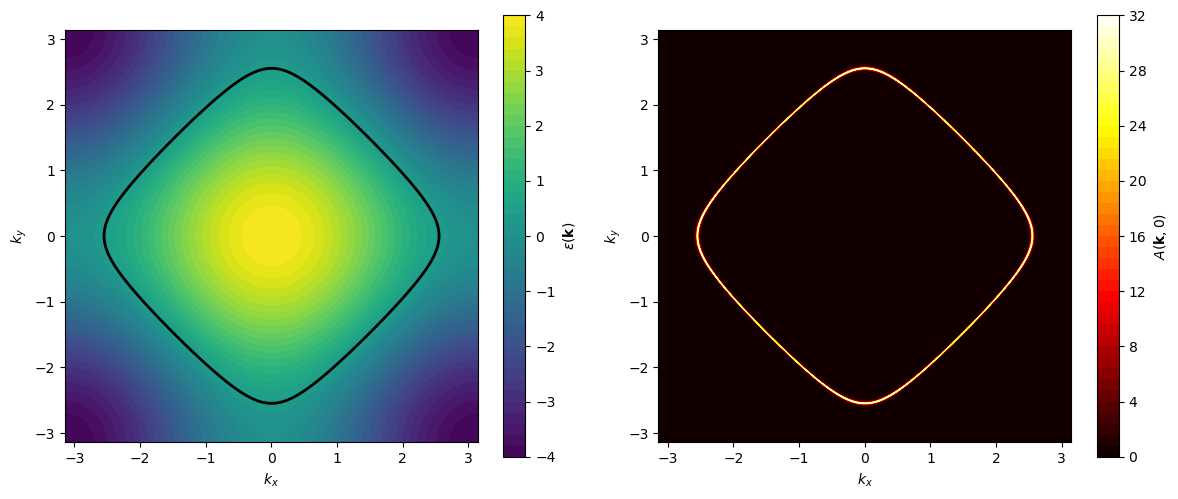

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define lattice and compute energies ---
square = LATTICE(dim=2, tp=0.)
nk = 1000
k_mesh, _ = square.get_k_mesh(nk)
square.get_e_k(nk)
kx = np.linspace(-np.pi, np.pi, nk)
ky = np.linspace(-np.pi, np.pi, nk)

# Extract energies
eps = np.array([square.e_k[k][0,0].real for k in k_mesh])
eps = eps.reshape((nk, nk))

# --- Compute A(k,0) ---
eta = 0.01  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=1.1, beta=1/1)
Ak0 = (1/np.pi) * eta / (eta**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

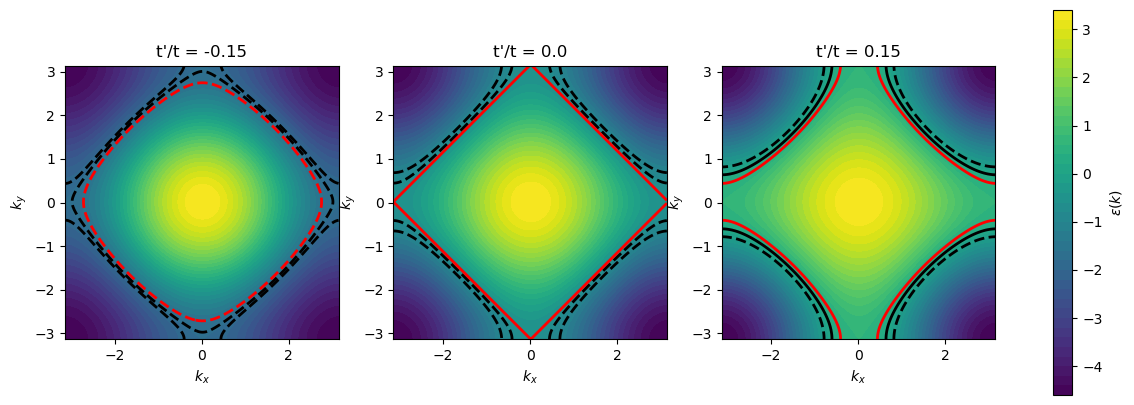

In [58]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [-0.15, 0., 0.15]

nk = 200
kx = np.linspace(-np.pi, np.pi, nk)
ky = np.linspace(-np.pi, np.pi, nk)

T = 0.01
n_list = [0.8, 0.9, 1.]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tp in zip(axes, tp_list):
    square = LATTICE(dim=2, tp=tp)
    k_mesh, _ = square.get_k_mesh(nk)
    square.get_e_k(nk)
    e_k = square.e_k.data[:,0,0].real.reshape((nk, nk))

    cf = ax.contourf(kx, ky, e_k, levels=50)

    mu_list = [get_mu(e_k=square.e_k, n_goal=n, beta=1/T) for n in n_list]
    ax.contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    ax.contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(f"t'/t = {tp}")
    ax.set_aspect('equal')

fig.colorbar(cf, ax=axes, label=r'$\varepsilon(k)$')
plt.show()

In [56]:
import numpy as np

T = 0.01
n = 0.75
nk = 100
n_iw = 256

lattice = LATTICE(dim=2, tp=-0.4)

iw_mesh = MeshImFreq(beta=1/T, S='Fermion', n_iw=n_iw)
S_iw = Gf(mesh=iw_mesh, target_shape=[1,1])
S_iw << 0

lattice.get_e_k(nk)
mu = get_mu(e_k=lattice.e_k, n_goal=n, beta=1/T)

G_iwk = lattice_dyson_g0_wk(mu, lattice.e_k, iw_mesh)
chi0 = imtime_bubble_chi0_wk(G_iwk, nw=1)
chi0_mesh = chi0.data[0, :, 0, 0].real.reshape((nk, nk))

max_idx = np.unravel_index(np.argmax(chi0_mesh), chi0_mesh.shape)
k_vec = 2*np.array(max_idx) / nk

print(k_vec)


╔╦╗╦═╗╦╔═╗ ╔═╗  ┌┬┐┌─┐┬─┐┌─┐
 ║ ╠╦╝║║═╬╗╚═╗   │ ├─┘├┬┘├┤ 
 ╩ ╩╚═╩╚═╝╚╚═╝   ┴ ┴  ┴└─└  
Two-Particle Response Function tool-box 

beta  = 100.0
nk    = 10000
nw    = 512
norb  = 1

Approx. Memory Utilization: 0.23 GB

--> fourier_wk_to_wr
--> fourier_wr_to_tr
--> chi0_w0r_from_grt_PH (bubble in tau & r)
--> chi_wk_from_chi_wr (r->k)
[1.74 0.26]


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-07 17:16:20.290992


[Parallel(n_jobs=6)]: Done   2 out of  11 | elapsed:   44.8s remaining:  3.4min
[Parallel(n_jobs=6)]: Done   4 out of  11 | elapsed:   50.1s remaining:  1.5min
[Parallel(n_jobs=6)]: Done   6 out of  11 | elapsed:   54.9s remaining:   45.7s
[Parallel(n_jobs=6)]: Done   8 out of  11 | elapsed:  1.6min remaining:   36.6s
[Parallel(n_jobs=6)]: Done  11 out of  11 | elapsed:  1.7min finished


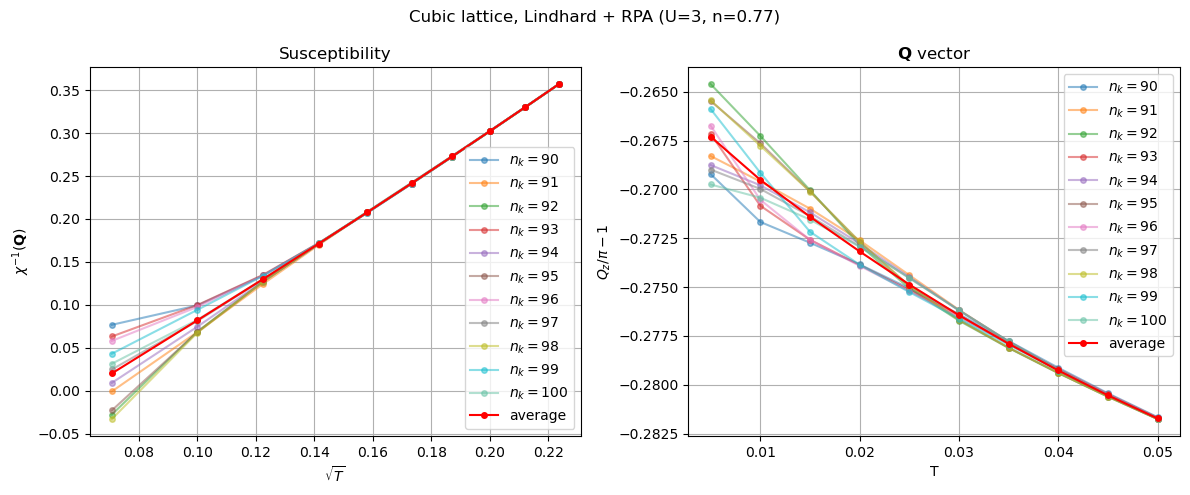

In [ ]:
U = 3
n = 0.77
T_list = np.linspace(0.005, 0.05, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard + RPA (U={U}, n={n})'

nk_list = list(range(90, 101, 1))
sweep_dict = [{'par_dict': par_dict, 'nk': nk} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig, alpha=0.5)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig, fit = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), x_exp=0.5,
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   5 | elapsed:   22.0s remaining:   33.0s
[Parallel(n_jobs=6)]: Done   3 out of   5 | elapsed:   57.9s remaining:   38.6s
[Parallel(n_jobs=6)]: Done   5 out of   5 | elapsed:  3.1min finished


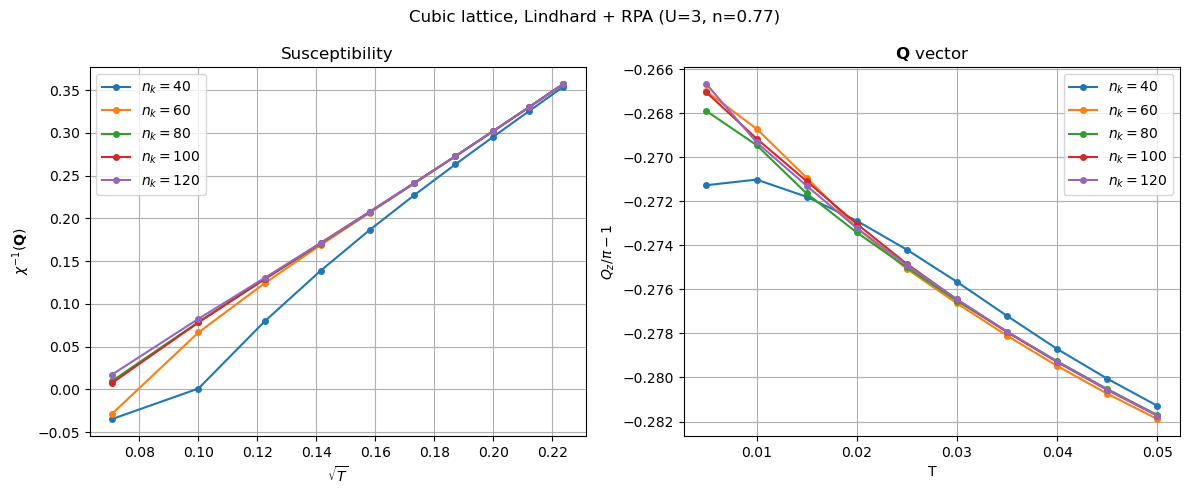

In [ ]:
U = 3
n = 0.77
T_list = np.linspace(0.005, 0.05, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard + RPA (U={U}, n={n})'

nk_list = list(range(40, 121, 20))
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'nk_avg': (5,2)} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig)

plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Starting serial run at: 2026-04-13 22:45:27.605227
Starting serial run at: 2026-04-13 22:45:27.605432
Starting serial run at: 2026-04-13 22:45:27.607204
Starting serial run at: 2026-04-13 22:45:27.622717


[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:   25.9s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   35.3s remaining:   35.3s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  1.4min finished


Completed 10 jobs in 74.38 seconds | U=3.000, T=0.050, n=0.770
Completed 10 jobs in 1.64 seconds | U=3.000, T=0.050, n=0.770


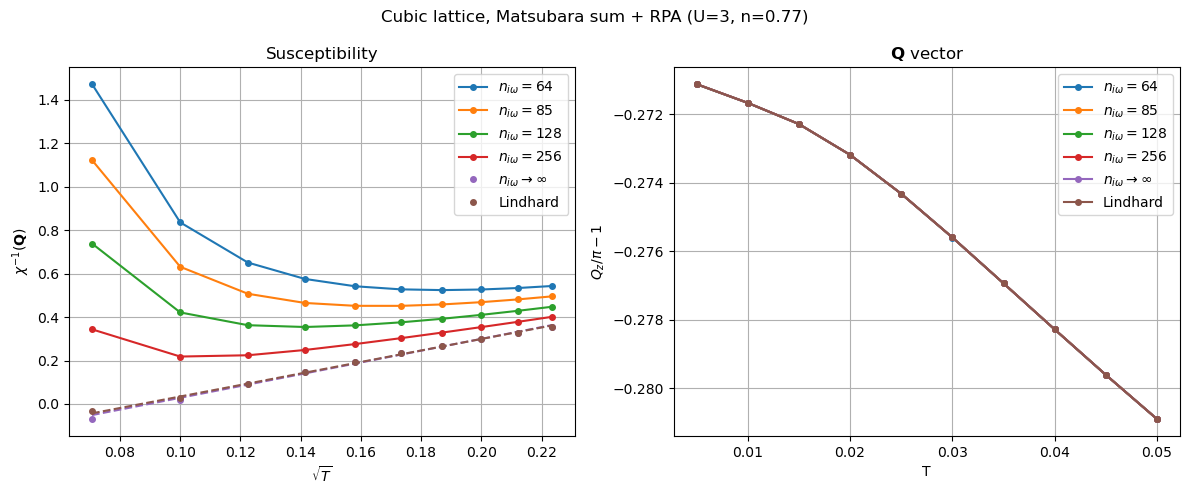

In [59]:
U = 3
n = 0.77
T_list = np.linspace(0.005, 0.05, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 50
n_iw_list = 256//np.array([4,3,2,1])
S_list = [[np.zeros(n_iw) for _ in T_list] for n_iw in n_iw_list]

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iw_list': S_iw_list, 'n_iw_extr': False} for S_iw_list in S_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for results in results_list:
    n_iw = len(results['S_iw_list'][0])
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=False, x_exp=0.5, title=title, label=f'$n_{{i\omega}}={n_iw}$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, S_iw_list=S_list[-1])
fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5, title=title, label=r'$n_{{i\omega}}\to\infty$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk)
fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5, title=title, label='Lindhard', figure=fig)

plt.show()

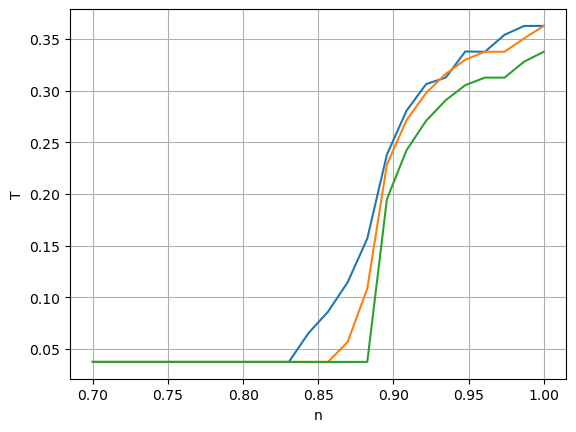

In [ ]:
U = 3
nk = 30
n_start = 0.7
n_stop = 1.
dn = (n_stop - n_start)/11
dT = 0.025
tp_list = [0., 0.1, 0.2]

Tc_list = []
for tp in tp_list:
    T = 0.05
    n = 0.7
    Xc = []
    pos_points = []
    neg_points = []

    while n < n_stop + dn/2:
        prev_invchi = None

        while True:
            par_dict = {'U': U, 'n': n, 'T': [T]}
            results = sweep_chirpa(par_dict, nk=nk, nk_avg=(10,1), tp=tp, verbose=False)
            invchi = results['invchi'][0]

            if invchi < 0:
                neg_points.append((n, T))
                prev_invchi = invchi
                T += dT
            else:
                pos_points.append((n, T))
                if prev_invchi is None:
                    Tc_seed = T - dT / 2
                else:
                    Tc_seed = T - dT - prev_invchi * dT / (invchi - prev_invchi)
                Xc.append(Tc_seed)
                break

        n += dn

    n_coarse = np.linspace(0.7, 1., len(Xc))
    plt.plot(n_coarse, Xc, label='T_c')

    Tc_list.append(Xc)

plt.grid()
plt.xlabel('n')
plt.ylabel('T')

plt.show()

In [71]:
U = 3
n_list = np.linspace(0.7, 1., 24)[-12:]
T_list = np.linspace(0., 0.01, 6)

nk = 100
tp_list = [0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-14 00:24:44.640785
Starting serial run at: 2026-04-14 00:24:44.649348
Starting serial run at: 2026-04-14 00:24:44.649428
Starting serial run at: 2026-04-14 00:24:44.709129
Starting serial run at: 2026-04-14 00:24:44.711386
Starting serial run at: 2026-04-14 00:24:44.711432
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.5min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  4.6min remaining: 13.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed: 10.3min remaining:  7.3min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed: 10.3min remaining:  3.4min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed: 10.5min finished


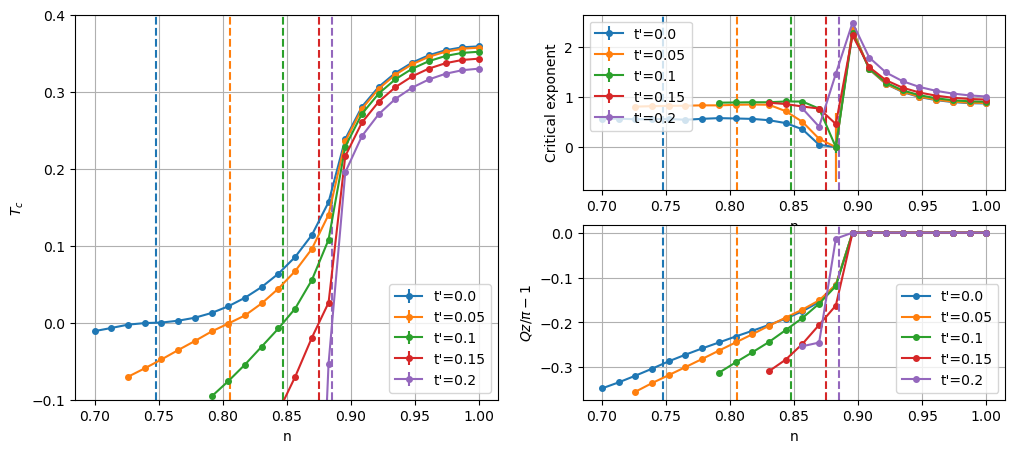

In [73]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0.1, 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

tp_list = [0., 0.05, 0.1, 0.15, 0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.show()

In [78]:
U = 3
n_list = np.linspace(0.7, 1., 24)[6:]
T_list = np.linspace(0., 0.05, 6)

nk = 100
tp_list = [-0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-14 01:56:04.438604
Starting serial run at: 2026-04-14 01:56:04.440885
Starting serial run at: 2026-04-14 01:56:04.450943
Starting serial run at: 2026-04-14 01:56:04.462783
Starting serial run at: 2026-04-14 01:56:04.496143
Starting serial run at: 2026-04-14 01:56:04.516338
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  5.1min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.3min


Starting serial run at: 2026-04-14 02:06:22.737360


Starting serial run at: 2026-04-14 02:06:33.429661
[Parallel(n_jobs=6)]: Done   9 out of  18 | elapsed: 10.6min remaining: 10.6min


Starting serial run at: 2026-04-14 02:06:43.560805
[Parallel(n_jobs=6)]: Done  11 out of  18 | elapsed: 11.5min remaining:  7.3min


...

Starting serial run at: 2026-04-14 02:42:10.886671
Starting serial run at: 2026-04-14 02:42:10.886707
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min


Starting serial run at: 2026-04-14 02:47:07.494112


Starting serial run at: 2026-04-14 02:47:13.873525


Starting serial run at: 2026-04-14 02:47:16.427747


Starting serial run at: 2026-04-14 02:47:17.937218
[Parallel(n_jobs=6)]: Done   5 out of  14 | elapsed:  5.3min remaining:  9.6min
[Parallel(n_jobs=6)]: Done   7 out of  14 | elapsed: 10.6min remaining: 10.6min
[Parallel(n_jobs=6)]: Done   9 out of  14 | elapsed: 10.9min remaining:  6.1min
[Parallel(n_jobs=6)]: Done  11 out of  14 | elapsed: 11.0min remaining:  3.0min
[Parallel(n_jobs=6)]: Done  14 out of  14 | elapsed: 13.6min finished


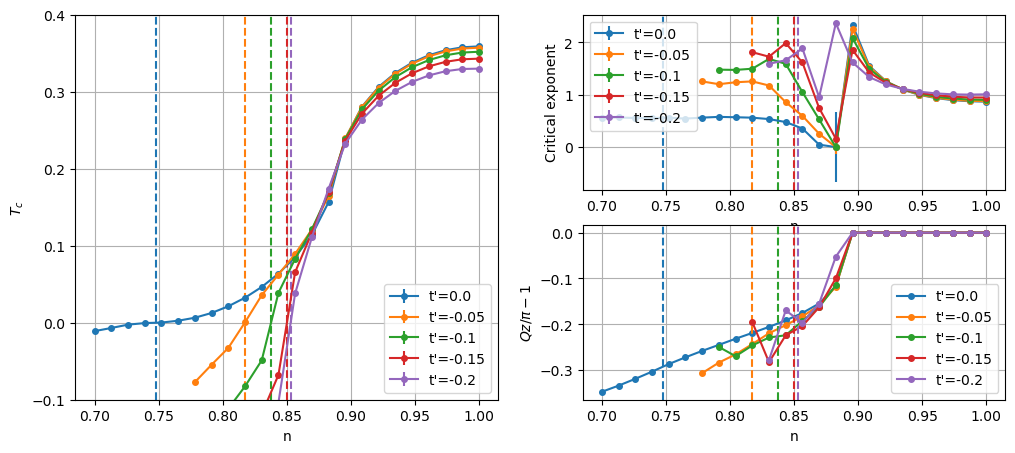

In [80]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0.1, 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

tp_list = [0., -0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.show()